# PART 13

Haikal Ali_1103223071_TK46GAB

# SLC 13 — Deploying scikit-learn Models in Production

Notebook ini dibuat dari materi **Deploying scikit-learn Models in Production**.  
Materi yang bersifat teori ditulis sebagai markdown. Materi yang memiliki contoh kode ditulis sebagai cell kode.

## Tujuan Materi

Bab ini membahas praktik deployment model scikit-learn ke lingkungan produksi, termasuk penyimpanan model, scaling, monitoring, pengelolaan siklus hidup model, dan pipeline deployment.

Topik yang dibahas:

- Overview of model deployment
- Serialization and persistence techniques
- Scaling models for production
- Monitoring and updating deployed models
- Managing the model life cycle
- Setting up deployment pipelines

## Technical Requirements

Materi menyarankan penggunaan environment Python yang terisolasi agar pekerjaan tidak tercampur dengan instalasi atau library Python lain.

Kebutuhan teknis:

- Git >= 2.46.x
- Python >= 3.9.x
- Repository GitHub yang sudah di-clone
- Environment Python dari file `requirements.txt`

# 1. Overview of Model Deployment

Deployment model berarti memindahkan model dari environment pengembangan ke environment produksi agar prediksi dapat digunakan oleh user atau sistem lain.

Deployment melibatkan:

- Menyiapkan artifact model
- Menyimpan metadata model
- Menyajikan prediksi dengan latency dan throughput yang sesuai
- Memastikan performa model tetap baik saat data berubah

## Getting Ready

Bagian ini membuat model sederhana menggunakan `LogisticRegression`, lalu model tersebut akan disimpan dan dimuat kembali.

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from joblib import dump, load

X, y = make_classification(
  n_samples=1000,
  n_features=20,
  random_state=2024
)

clf = LogisticRegression()
clf.fit(X, y)

LogisticRegression()

## Menyimpan dan Memuat Model

Model yang sudah dilatih dapat disimpan ke disk menggunakan `joblib`, lalu dimuat kembali di environment lain.

In [2]:
dump(clf, "model.joblib")

['model.joblib']

In [3]:
clf_loaded = load("model.joblib")

In [4]:
incoming = np.random.rand(1, 20)
print(clf_loaded.predict(incoming))

[1]


## Cara Kerja

`joblib` direkomendasikan untuk menyimpan model scikit-learn karena menangani array NumPy secara efisien. Setelah model disimpan sebagai file `.joblib`, model dapat dimuat kembali dan digunakan untuk prediksi dengan perilaku yang sama seperti model asli.

# 2. Serialization and Persistence Techniques

Serialization digunakan untuk menyimpan model agar dapat digunakan kembali tanpa perlu melatih ulang. Materi ini menunjukkan dua teknik:

- `pickle`
- `joblib`

Materi juga menyebutkan bahwa format seperti ONNX atau PMML dapat digunakan untuk environment non-Python, meskipun tidak semua estimator scikit-learn didukung.

## Getting Ready

Bagian ini melatih model `RandomForestClassifier`, lalu menyimpannya dengan `pickle` dan `joblib`.

In [5]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import pickle
from joblib import dump, load

X, y = make_classification(
  n_samples=500,
  n_features=15,
  random_state=2024
)

rf = RandomForestClassifier(
  n_estimators=10,
  random_state=2024
)

rf.fit(X, y)

RandomForestClassifier(n_estimators=10, random_state=2024)

## Serialize dengan Pickle dan Joblib

In [6]:
with open("rf.pkl", "wb") as f:
  pickle.dump(rf, f)

In [7]:
dump(rf, "rf.joblib")

['rf.joblib']

In [8]:
with open("rf.pkl", "rb") as f:
  rf1 = pickle.load(f)

In [9]:
rf2 = load("rf.joblib")

In [10]:
assert np.array_equal(
  rf.predict(X[:5]),
  rf1.predict(X[:5])
)

assert np.array_equal(
  rf.predict(X[:5]),
  rf2.predict(X[:5])
)

## Cara Kerja

`pickle` dapat digunakan untuk menyimpan object Python, tetapi `joblib` lebih direkomendasikan untuk model scikit-learn karena lebih efisien untuk object yang memiliki array NumPy besar.

File hasil serialization harus dipercaya. Jangan memuat file `pickle` atau `joblib` dari sumber yang tidak tepercaya. Model yang disimpan dengan satu versi scikit-learn juga dapat bermasalah jika dimuat dengan versi scikit-learn yang berbeda.

## Serialization

Serialization mengubah model menjadi byte stream, yaitu representasi biner yang dapat disimpan, dipindahkan, dan dimuat kembali. Teknik ini membantu model digunakan di berbagai sistem tanpa perlu melatih ulang dari awal.

# 3. Scaling Models for Production

Pada deployment produksi, model dapat menghadapi dataset besar, kebutuhan inference tinggi, atau infrastruktur terdistribusi. Materi ini membahas:

- `n_jobs`
- Parallelism menggunakan `joblib`
- Backend eksternal seperti Dask
- Batch serving

## Getting Ready

Bagian ini membuat data sintetis, melatih `RandomForestClassifier`, lalu mengukur prediksi batch dan cross-validation paralel.

In [11]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

X, y = make_classification(
  n_samples=2000,
  n_features=50,
  random_state=2024
)

clf = RandomForestClassifier(
  n_estimators=100,
  n_jobs=-1,
  random_state=2024
)

clf.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=2024)

## Mengukur Latency Batch

In [12]:
batch = np.random.rand(1000, 50)

start = time.time()
clf.predict(batch)

print("Time:", time.time() - start)

Time: 0.04651951789855957


## Cross-Validation Paralel

In [13]:
scores = cross_val_score(
  RandomForestClassifier(n_estimators=50),
  X,
  y,
  cv=3,
  n_jobs=-1
)

print("CV Accuracy:", np.mean(scores))

CV Accuracy: 0.8759989374682028


## Dask sebagai Backend Opsional

Materi menyebutkan Dask sebagai library untuk distributed computation. Contoh berikut bersifat opsional.

In [14]:
# from dask.distributed import Client
# from dask_ml.model_selection import GridSearchCV as daskGSCV

## Cara Kerja

Banyak estimator scikit-learn mendukung parameter `n_jobs` untuk parallelization. Untuk workload yang lebih besar, Dask dapat digunakan sebagai backend terdistribusi. Batch serving lebih efisien daripada prediksi satu per satu karena overhead lebih rendah dan pemanfaatan CPU lebih baik.

# 4. Monitoring and Updating Deployed Models

Setelah model berjalan di produksi, performanya dapat menurun karena perubahan distribusi data atau kondisi eksternal. Materi ini membahas monitoring, drift, dan pembaruan model.

Bagian ini menggunakan `SGDClassifier` karena mendukung `partial_fit`.

## Getting Ready

Bagian ini membuat data training awal dan data streaming yang dibagi menjadi beberapa batch.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification

X_train, y_train = make_classification(
  n_samples=500,
  n_features=10,
  random_state=2024
)

X_pub, y_pub = make_classification(
  n_samples=200,
  n_features=10,
  random_state=2025
)

stream_batches = np.array_split(X_pub, 4)
stream_labels = np.array_split(y_pub, 4)

## Training Incremental dan Monitoring Batch

In [16]:
clf = SGDClassifier(
  loss="log_loss",
  random_state=2024,
  warm_start=True
)

clf.partial_fit(
  X_train,
  y_train,
  classes=np.unique(y_train)
)

SGDClassifier(loss='log_loss', random_state=2024, warm_start=True)

In [17]:
batch_scores = []

for xb, yb in zip(stream_batches, stream_labels):
  yf = clf.predict(xb)
  batch_scores.append(np.mean(yf == yb))

batch_scores

[np.float64(0.38), np.float64(0.3), np.float64(0.36), np.float64(0.38)]

## Retraining Jika Akurasi Turun

In [18]:
if min(batch_scores) < 0.8:
  clf.partial_fit(X_pub, y_pub)

## Visualisasi Akurasi per Batch

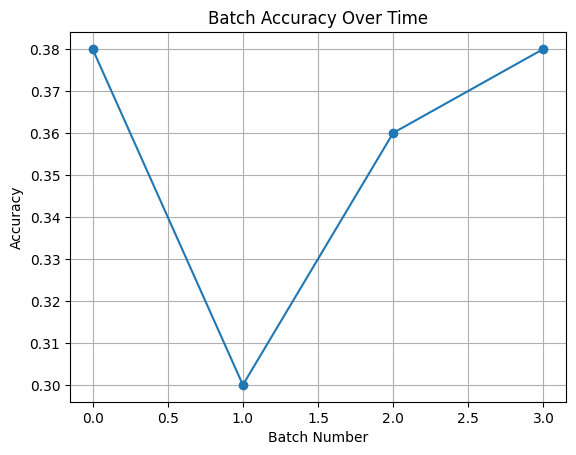

In [19]:
plt.plot(batch_scores, marker="o")
plt.title("Batch Accuracy Over Time")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## Cara Kerja

Model yang mendukung `partial_fit` dan `warm_start`, seperti `SGDClassifier`, dapat dilatih kembali saat data baru masuk. Monitoring akurasi batch dapat digunakan sebagai detektor sederhana untuk melihat penurunan performa. Jika performa turun di bawah threshold, model dapat diperbarui menggunakan data streaming.

# 5. Managing the Model Life Cycle

Model tidak cukup hanya dilatih sekali. Model dapat memburuk dari waktu ke waktu karena data berubah atau target prediksi berubah. Materi ini membahas:

- Versioning
- Reproducibility
- Document control
- Konsistensi antara training dan serving environment

## Getting Ready

Bagian ini melatih model dan menyiapkan metadata untuk disimpan bersama artifact model.

In [20]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from joblib import dump
import json

X, y = make_classification(
  n_samples=800,
  n_features=20,
  random_state=2024
)

clf = RandomForestClassifier(
  n_estimators=50,
  random_state=2024
)

clf.fit(X, y)

RandomForestClassifier(n_estimators=50, random_state=2024)

## Menyimpan Artifact dan Metadata

In [21]:
version = "v1.0"

dump(clf, f"rf_{version}.joblib")

['rf_v1.0.joblib']

In [22]:
meta = {
  "version": version,
  "sklearn": "1.3.2",
  "numpy": str(np.__version__)
}

with open(f"rf_{version}_metadata.json", "w") as f:
  json.dump(meta, f)

## Snapshot Performa Validasi

In [23]:
Xv = X[:100]
yv = y[:100]

yv_pred = clf.predict(Xv)
val_acc = accuracy_score(yv, yv_pred)

with open(f"rf_{version}_val.txt", "w") as f:
  f.write(f"{val_acc:.4f}")

val_acc

1.0

## Cara Kerja

Model sebaiknya disimpan bersama informasi pendukung seperti versi model, versi library, dan hasil validasi. Metadata membantu proses pelacakan, rollback, dan reproduksi hasil ketika model digunakan atau diperbarui di masa depan.

# 6. Setting Up Deployment Pipelines

Deployment yang andal membutuhkan automation. Materi ini menunjukkan cara menggabungkan preprocessing, model, serialization, validation check, dan logic deployment ke dalam satu pipeline.

## Getting Ready

Bagian ini membuat pipeline yang terdiri dari `StandardScaler` dan `LogisticRegression`.

In [24]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from joblib import dump, load
from sklearn.metrics import accuracy_score

X, y = make_classification(
  n_samples=500,
  n_features=10,
  random_state=2024
)

pipe = Pipeline([
  ("scale", StandardScaler()),
  ("clf", LogisticRegression())
])

pipe.fit(X, y)

Pipeline(steps=[('scale', StandardScaler()), ('clf', LogisticRegression())])

## Export dan Load Pipeline

In [25]:
dump(pipe, "pipeline.joblib")

['pipeline.joblib']

In [26]:
prod_pipe = load("pipeline.joblib")

## Simulasi CI Validation

In [27]:
Xt, yt = (
  np.random.rand(100, 10),
  np.random.randint(0, 2, 100)
)

acc = accuracy_score(yt, prod_pipe.predict(Xt))
print("Validation accuracy:", acc)

Validation accuracy: 0.43


## Conditional Deployment

In [28]:
if acc > 0.8:
  print("Auto-deploy allowed")
else:
  print("Halt deployment and review")

Halt deployment and review


## Cara Kerja

`Pipeline` memastikan preprocessing dan prediksi terikat dalam satu object. Setelah pipeline diekspor, pipeline dapat dimuat kembali dan divalidasi sebagai satu kesatuan. Logic validasi dapat digunakan di CI/CD/CT agar model hanya dipromosikan jika memenuhi threshold performa.

# 7. Practical Exercises in Model Deployment

Bagian akhir materi berisi latihan praktis untuk memperkuat konsep deployment model scikit-learn.

## Exercise 1: Saving and Reloading a Model Pipeline for Deployment

Langkah implementasi:

1. Load libraries
2. Create and train the pipeline
3. Save and reload the pipeline
4. Generate new predictions

## Exercise 2: Monitoring Model Accuracy Over Time

Langkah implementasi:

1. Load libraries
2. Simulate the streaming setup
3. Train and evaluate incrementally
4. Plot batch accuracy

## Exercise 3: Automating Deployment Checks Using Validation Thresholds

Langkah implementasi:

1. Load libraries
2. Train and export the model
3. Load and validate with test data
4. Conditionally approve the deployment